# Acompanhamento: informação irrelevante

Painel das execuções do estudo de informação irrelevante
(`rodar_informacao_irrelevante.sh`). **Não carrega modelo nem usa GPU**: só lê
os arquivos em `results/irrelevant_info/`. Pode ser aberto enquanto as
execuções rodam; para atualizar, rode todas as células de novo
(*Run All*).

0. **Fila de modelos** (`rodar_fila.sh`): o que está em cada GPU, o que falta,
   o que terminou e o que falhou.
1. **Status:** o que está rodando, em que fase, quanto falta.
2. **Comportamento:** quanto cada frase desvia a resposta, contra o controle.
   Funciona com execuções pela metade.
3. **Ativações e gabarito:** assim que as capturas existem.
4. **Comparação entre modelos**, com as camadas em profundidade relativa
   (camada ÷ nº de camadas).

Para o detalhe de uma execução (gráficos por camada, tabelas por problema),
abra o notebook dela, listado no fim.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "interp").is_dir():
    if ROOT == ROOT.parent:
        raise RuntimeError("raiz do repositório não encontrada")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.interp import summary as S

RESULTS = ROOT / "results" / "irrelevant_info"
SHOW_TESTS = False          # True inclui as execuções de teste (--teste, 6 problemas)

INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURF, "axes.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9, "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 60)

def model_size(name):
    import re
    m = re.search(r"(\d+(?:\.\d+)?)B", name)
    return float(m.group(1)) if m else 1e9

## 0. Fila de modelos

Estado do escalonador (`bash rodar_fila.sh`), lido de
`results/irrelevant_info/fila_estado.json` (e `fila_estado_teste.json` para a
fila de teste). **Fase 1:** um modelo de 1 GPU em cada GPU. **Fase 2:** os
modelos de 2 GPUs, um de cada vez, só quando não sobrar nenhum de 1 GPU.
Uma execução que falha é tentada de novo uma vez; o motivo fica em *detalhe*.


In [ ]:
STATE_COLORS = {"rodando": "#e6f4ec", "rodando?": "#fbf1df", "falhou": "#fbe4e4",
                "sem acesso": "#efeeea", "recusado": "#efeeea"}
found = False
for teste in (False, True):
    q = S.queue_status(RESULTS, teste=teste)
    if not q:
        continue
    found = True
    when = pd.Timestamp(q["atualizado"], unit="s", tz="UTC").tz_convert("America/Sao_Paulo").strftime("%d/%m %H:%M") \
        if q["atualizado"] else "—"
    print(f"Fila {'de TESTE (6 problemas)' if teste else 'completa (90 problemas)'} | escalonador {q['escalonador']} "
          f"| estado gravado em {when}")
    if q["gpus"] is not None:
        display(q["gpus"])
    t = q["tabela"]
    print("  " + " | ".join(f"{n} {s}" for s, n in t.estado.value_counts().items()))
    display(t.style.apply(lambda r: [f"background-color: {STATE_COLORS.get(r['estado'], '')}"] * len(r), axis=1)
             .set_properties(subset=["detalhe"], **{"white-space": "pre-wrap", "text-align": "left",
                                                    "max-width": "520px"}))
if not found:
    print("A fila ainda não rodou (bash rodar_fila.sh --listar mostra a fila configurada).")


## 1. Status das execuções

In [2]:
status = S.run_status(RESULTS)
if not SHOW_TESTS and len(status):
    status = status[status.problemas >= 90]
if status.empty:
    print("Nenhuma execução encontrada em", RESULTS)
else:
    runs = sorted(status.index, key=lambda r: model_size(status.loc[r, "modelo"]))
    status = status.loc[runs]
    COLOR = {status.loc[r, "modelo"]: MODEL_COLORS[i % len(MODEL_COLORS)] for i, r in enumerate(runs)}
    def highlight(row):
        color = "#e6f4ec" if row["estado"] == "rodando" else ("" if "concluída" in row["etapa"] else "#fbf1df")
        return [f"background-color: {color}"] * len(row)
    display(status.style.apply(highlight, axis=1))

,modelo,problemas,estado,etapa,gerações,capturas,última escrita
execução,,,,,,,
Qwen3-8B_one_shot_frac0.30_seed42,Qwen3-8B,90,parada/terminada,concluída,810/≤810,90/90,25/09 12:32


*Verde*: rodando. *Amarelo*: parada antes de terminar; rode o mesmo comando
`rodar_informacao_irrelevante.sh` de novo para retomar. "Restante" vale só
para a fase atual (são 5 fases: 3 de geração, captura e gabarito).

## 2. Comportamento

**Desvio** = resposta final diferente da resposta sem frase, ou sem resposta
(geração truncada). Cada frase é comparada com o controle do seu cenário:
`control` (a mesma pergunta gerada de novo) para o cenário *prompt*, e
`reasoning:control` (o raciocínio cortado no mesmo ponto, sem frase) para o
*reasoning*. p = teste exato de Fisher. Em execuções em andamento, cada
condição usa os problemas que já têm aquela geração (coluna `n`).

In [3]:
ORDER = ["clean", "control", "prompt:estava_contando_1+1", "prompt:parei_para_respirar", "prompt:qual_o_valor",
         "reasoning:control", "reasoning:estava_contando_1+1", "reasoning:parei_para_respirar", "reasoning:qual_o_valor"]
beh = {}
for run in status.index:
    b = S.behavior(S.load_generations(RESULTS / run))
    if len(b):
        beh[status.loc[run, "modelo"]] = b.reindex([c for c in ORDER if c in b.index])

if beh:
    rate = pd.DataFrame({m: b.taxa_desvio * 100 for m, b in beh.items()}).reindex(ORDER)
    pval = pd.DataFrame({m: b.get("p_vs_controle") for m, b in beh.items()}).reindex(ORDER)
    n = pd.DataFrame({m: b.n for m, b in beh.items()}).reindex(ORDER)
    table = pd.concat({"% desvio": rate, "p vs controle": pval, "n": n}, axis=1)
    display(table.style.format({c: ("{:.1f}" if c[0] == "% desvio" else "{:.3f}" if c[0] == "p vs controle" else "{:.0f}")
                                for c in table.columns}, na_rep="—"))
    acc = pd.DataFrame({m: {"acertos sem frase": int(b.loc["clean", "acertos"]), "problemas": int(b.loc["clean", "n"])}
                        for m, b in beh.items()}).T
    acc["acurácia"] = (acc["acertos sem frase"] / acc.problemas * 100).round(1).astype(str) + "%"
    display(acc)

,% desvio,p vs controle,n
,Qwen3-8B,Qwen3-8B,Qwen3-8B
condition,,,
clean,0.0,—,90
control,40.0,—,90
prompt:estava_contando_1+1,66.7,0.001,90
prompt:parei_para_respirar,66.7,0.001,90
prompt:qual_o_valor,64.4,0.002,90
reasoning:control,20.0,—,90
reasoning:estava_contando_1+1,53.3,0.000,90
reasoning:parei_para_respirar,23.3,0.718,90


,acertos sem frase,problemas,acurácia
Qwen3-8B,2,90,2.2%


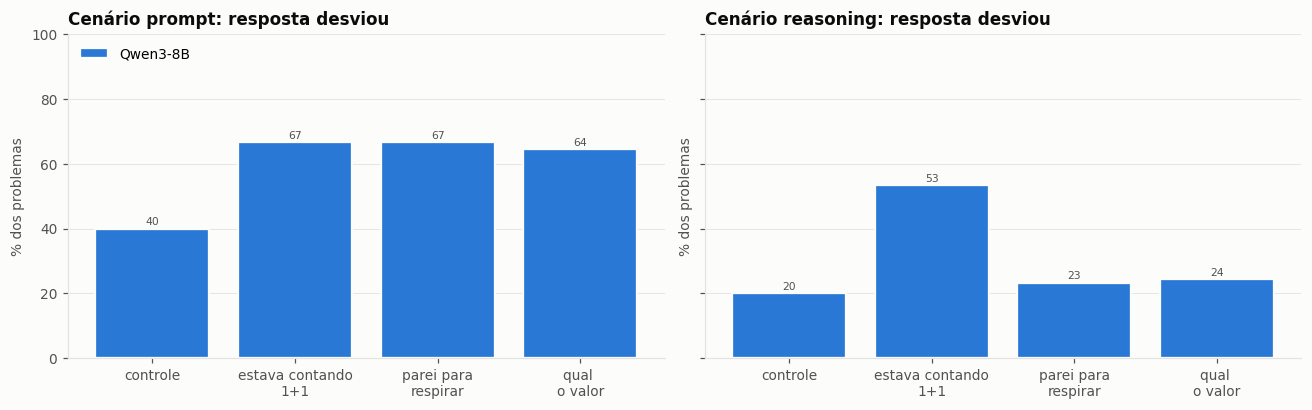

In [4]:
if beh:
    models = list(beh)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    for ax, scen, ctrl in zip(axes, ["prompt", "reasoning"], ["control", "reasoning:control"]):
        conds = [ctrl] + [c for c in ORDER if c.startswith(scen + ":") and c != ctrl]
        labels = ["controle"] + [c.split(":")[1].replace("_", " ").replace(" 1+1", "\n1+1")
                                 .replace("para ", "para\n").replace("o valor", "\no valor") for c in conds[1:]]
        x = np.arange(len(conds))
        w = 0.8 / len(models)
        for i, m in enumerate(models):
            vals = [beh[m].taxa_desvio.get(c, np.nan) * 100 for c in conds]
            bars = ax.bar(x - 0.4 + w * (i + 0.5), vals, width=w, color=COLOR[m], label=m,
                          edgecolor=SURF, linewidth=1.5)
            for b_, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.annotate(f"{v:.0f}", (b_.get_x() + b_.get_width() / 2, v), ha="center", va="bottom",
                                fontsize=7, color=INK2, xytext=(0, 1), textcoords="offset points")
        ax.set_xticks(x, labels)
        ax.set_title(f"Cenário {scen}: resposta desviou")
        ax.set_ylabel("% dos problemas")
        ax.set_ylim(0, 100)
        ax.grid(axis="x", visible=False)
    axes[0].legend(loc="upper left")
    fig.tight_layout()

## 3. Ativações e resposta correta

Resumo das capturas de cada execução (aparece quando a fase 4 começa):

- **deslocamento faixa / última camada**: distância relativa do residual com ×
  sem frase, na faixa de referência (mesma profundidade relativa de 22–26 no
  Qwen3-8B) e na última camada. `clean_padded` é o piso de ruído numérico.
- **convergência**: camada (mediana) a partir da qual a resposta do modelo é
  top-1 até o fim.
- **rank final / top-2 / top-5**: posição do dígito correto na última camada,
  no ponto em que o modelo erra (0 = seria escolhido).
- **camada da escolha**: camada em que o dígito errado passa o correto e não
  perde mais a frente.

In [5]:
internals = {}
for run in status.index:
    I = S.internals(RESULTS / run)
    if I.get("n_captures"):
        internals[status.loc[run, "modelo"]] = I

for m, I in internals.items():
    print(f"{m}: {I['n_layers']} camadas | {I['n_captures']} problemas capturados | "
          f"faixa de referência {I['band'][0]}–{I['band'][1]}")
    cols = {"convergence": "convergência", "shift_band": "deslocamento faixa", "shift_last": "deslocamento última",
            "rank_final_mediano": "rank final", "pct_top2": "% top-2", "pct_top5": "% top-5",
            "camada_escolha": "camada da escolha"}
    t = I["table"].rename(columns=cols)[[c for c in cols.values() if c in I["table"].rename(columns=cols)]]
    display(t.style.format({"deslocamento faixa": "{:.3f}", "deslocamento última": "{:.3f}",
                            "% top-2": "{:.0f}", "% top-5": "{:.0f}"}, na_rep="—", precision=1))
if not internals:
    print("Nenhuma captura ainda (a fase 4 começa depois das gerações).")

Qwen3-8B: 36 camadas | 90 problemas capturados | faixa de referência 22–26


,convergência,deslocamento faixa,deslocamento última,rank final,% top-2,% top-5,camada da escolha
condition,,,,,,,
clean,34.0,—,—,2.0,26,80,24.0
clean_padded,34.0,0.011,0.012,2.0,26,80,24.0
prompt:estava_contando_1+1,34.0,0.023,0.024,2.0,27,78,24.0
prompt:parei_para_respirar,34.0,0.021,0.022,2.0,27,78,24.0
prompt:qual_o_valor,34.0,0.026,0.024,2.0,27,78,24.0
reasoning:estava_contando_1+1,34.0,0.033,0.149,2.0,27,76,24.0
reasoning:parei_para_respirar,34.0,0.033,0.163,2.0,26,77,24.0
reasoning:qual_o_valor,34.0,0.038,0.173,3.0,25,76,24.0


## 4. Comparação entre modelos

In [6]:
def mean_over(t, prefix, col):
    rows = [c for c in t.index if c.startswith(prefix)]
    return t.loc[rows, col].mean() if rows and col in t else np.nan

if internals:
    comp = {}
    for m, I in internals.items():
        t, L = I["table"], I["n_layers"]
        comp[m] = {
            "camadas": L,
            "convergência (camada)": t.loc["clean", "convergence"],
            "convergência (relativa)": t.loc["clean", "convergence"] / L,
            "camada da escolha": t.loc["clean"].get("camada_escolha", np.nan),
            "escolha (relativa)": t.loc["clean"].get("camada_escolha", np.nan) / L,
            "% dígito correto no top-5": t.loc["clean"].get("pct_top5", np.nan),
            "ruído: desloc. faixa": t.loc["clean_padded", "shift_band"] if "clean_padded" in t.index else np.nan,
            "prompt: desloc. faixa": mean_over(t, "prompt:", "shift_band"),
            "reasoning: desloc. faixa": mean_over(t, "reasoning:", "shift_band"),
            "reasoning: desloc. última": mean_over(t, "reasoning:", "shift_last"),
        }
    comp = pd.DataFrame(comp).T
    comp["prompt ÷ ruído"] = comp["prompt: desloc. faixa"] / comp["ruído: desloc. faixa"]
    comp["reasoning ÷ ruído"] = comp["reasoning: desloc. faixa"] / comp["ruído: desloc. faixa"]
    fmt = {c: "{:.3f}" for c in comp.columns}
    fmt.update({"camadas": "{:.0f}", "convergência (camada)": "{:.0f}", "camada da escolha": "{:.0f}",
                "convergência (relativa)": "{:.2f}", "escolha (relativa)": "{:.2f}",
                "% dígito correto no top-5": "{:.0f}", "prompt ÷ ruído": "{:.1f}×", "reasoning ÷ ruído": "{:.1f}×"})
    display(comp.style.format(fmt, na_rep="—"))

,camadas,convergência (camada),convergência (relativa),camada da escolha,escolha (relativa),% dígito correto no top-5,ruído: desloc. faixa,prompt: desloc. faixa,reasoning: desloc. faixa,reasoning: desloc. última,prompt ÷ ruído,reasoning ÷ ruído
Qwen3-8B,36,34,0.94,24,0.67,80,0.011,0.023,0.035,0.162,2.0×,3.0×


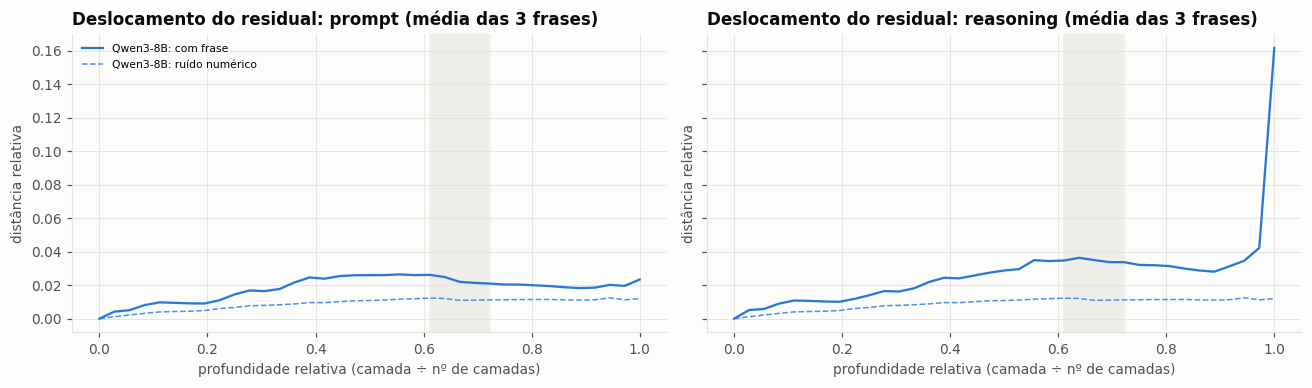

In [7]:
if internals:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
    for ax, scen in zip(axes, ["prompt", "reasoning"]):
        for m, I in internals.items():
            c = I["resid_curve"]
            frase = c[c.condition.str.startswith(scen + ":")].groupby("rel_depth").deslocamento.mean()
            ruido = c[c.condition == "clean_padded"].set_index("rel_depth").deslocamento
            ax.plot(frase.index, frase.values, color=COLOR[m], label=f"{m}: com frase")
            ax.plot(ruido.index, ruido.values, color=COLOR[m], linestyle="--", linewidth=1, alpha=0.8,
                    label=f"{m}: ruído numérico")
        ax.axvspan(22 / 36, 26 / 36, color="#efeeea", zorder=0)
        ax.set_title(f"Deslocamento do residual: {scen} (média das 3 frases)")
        ax.set_xlabel("profundidade relativa (camada ÷ nº de camadas)")
        ax.set_ylabel("distância relativa")
    axes[0].legend(loc="upper left", fontsize=7)
    fig.tight_layout()

A faixa sombreada é a profundidade de 22–26 no Qwen3-8B. Linhas cheias:
média das três frases; tracejadas: ruído numérico do mesmo modelo. Um efeito
só é da frase se a linha cheia ficar acima da tracejada da mesma cor.

## 5. Notebooks completos de cada execução

In [8]:
rows = []
for run in status.index:
    m = status.loc[run, "modelo"]
    frac = run.split("_frac")[1].split("_")[0]
    candidates = [ROOT / "notebooks" / "execucoes" / f"informacao_irrelevante_{m}_frac{frac}.ipynb"]
    if m == "Qwen3-8B" and frac == "0.30":
        candidates.append(ROOT / "notebooks" / "informacao_irrelevante_ativacoes.ipynb")
    found = next((p for p in candidates if p.exists()), None)
    rows.append({"execução": run, "notebook": str(found.relative_to(ROOT)) if found else "— (gerado ao terminar)"})
pd.DataFrame(rows).set_index("execução")

,notebook
execução,
Qwen3-8B_one_shot_frac0.30_seed42,notebooks/informacao_irrelevante_ativacoes.ipynb
